# Data Understanding
## Data Collection

Pada proyek ini, data polutan udara dikumpulkan dalam bentuk deret waktu harian untuk tiga variabel utama, yaitu CO, SO₂, dan NO₂. Data tersebut disimpan dalam format CSV dan dapat dibuka menggunakan library Pandas untuk dianalisis lebih lanjut.

Dataset yang digunakan dalam proyek ini adalah file yang berada di folder:

- ../../data/polutan/CO.csv
- ../../data/polutan/SO2.csv
- ../../data/polutan/NO2.csv

### Hasil CSV
Berikut adalah tampilan awal dari dataset tersebut.

1. CO

In [1]:
import pandas as pd

df = pd.read_csv("../../data/polutan/CO.csv")
df.head(5)

,date,feature_index,CO
0,2025-09-03T00:00:00.000Z,0,0.025086
1,2025-09-04T00:00:00.000Z,0,0.032756
2,2025-09-02T00:00:00.000Z,0,0.023202
3,2025-08-30T00:00:00.000Z,0,NaN
4,2025-08-31T00:00:00.000Z,0,NaN


2. SO₂

In [2]:
df = pd.read_csv("../../data/polutan/SO2.csv")
df.head(5)

,date,feature_index,SO2
0,2025-09-20T00:00:00.000Z,0,NaN
1,2025-09-16T00:00:00.000Z,0,-0.000043
2,2025-09-18T00:00:00.000Z,0,NaN
3,2025-09-15T00:00:00.000Z,0,0.000128
4,2025-09-14T00:00:00.000Z,0,0.000045


3. NO₂

In [3]:
df = pd.read_csv("../../data/polutan/NO2.csv")
df.head(5)

,date,feature_index,NO2
0,2025-09-30T00:00:00.000Z,0,NaN
1,2025-10-01T00:00:00.000Z,0,0.000028
2,2025-10-02T00:00:00.000Z,0,0.000027
3,2025-10-06T00:00:00.000Z,0,0.000044
4,2025-10-04T00:00:00.000Z,0,0.000039


---

## Eksplorasi Data
### Missing Values

_Missing values_ adalah nilai yang hilang atau tidak terisi pada dataset. Dalam data deret waktu polutan, kondisi ini bisa terjadi karena data tidak tercatat pada hari tertentu atau sensor tidak berhasil membaca konsentrasi pada waktu tertentu. Pada tahap ini, kita mengecek dua hal:

1. tanggal yang hilang dari rentang waktu
2. jumlah nilai kosong pada kolom konsentrasi polutan

#### 1. Tanggal yang Hilang

1. CO

In [4]:
import pandas as pd

df = pd.read_csv("../../data/polutan/CO.csv")
df['date'] = pd.to_datetime(df['date'])

start_date = df['date'].min()
end_date = df['date'].max()
full_range = pd.date_range(start=start_date, end=end_date, freq='D')

missing_dates = full_range.difference(df['date'])

print(f"Jumlah hari missing: {len(missing_dates)}")
print(missing_dates)

Jumlah hari missing: 0
DatetimeIndex([], dtype='datetime64[ns, UTC]', freq='D')


2. SO₂

In [5]:
import pandas as pd

df = pd.read_csv("../../data/polutan/SO2.csv")
df['date'] = pd.to_datetime(df['date'])

start_date = df['date'].min()
end_date = df['date'].max()
full_range = pd.date_range(start=start_date, end=end_date, freq='D')

missing_dates = full_range.difference(df['date'])

print(f"Jumlah hari missing: {len(missing_dates)}")
print(missing_dates)

Jumlah hari missing: 0
DatetimeIndex([], dtype='datetime64[ns, UTC]', freq='D')


3. NO₂

In [6]:
import pandas as pd

df = pd.read_csv("../../data/polutan/NO2.csv")
df['date'] = pd.to_datetime(df['date'])

start_date = df['date'].min()
end_date = df['date'].max()
full_range = pd.date_range(start=start_date, end=end_date, freq='D')

missing_dates = full_range.difference(df['date'])

print(f"Jumlah hari missing: {len(missing_dates)}")
print(missing_dates)

Jumlah hari missing: 0
DatetimeIndex([], dtype='datetime64[ns, UTC]', freq='D')


#### 2. Data yang Hilang

Selain tanggal, kita juga mengecek jumlah nilai `NaN` pada kolom konsentrasi polutan.

1. CO

In [7]:
df = pd.read_csv("../../data/polutan/CO.csv")
print("Jumlah missing value CO:", df['CO'].isna().sum())

Jumlah missing value CO: 116


2. SO₂

In [8]:
df = pd.read_csv("../../data/polutan/SO2.csv")
print("Jumlah missing value SO2:", df['SO2'].isna().sum())

Jumlah missing value SO2: 83


3. NO₂

In [9]:
df = pd.read_csv("../../data/polutan/NO2.csv")
print("Jumlah missing value NO2:", df['NO2'].isna().sum())

Jumlah missing value NO2: 111


---

### Outliers

_Outliers_ adalah data yang sangat jauh dari pola umum dataset. Pada data kualitas udara, outlier bisa terjadi karena sensor membaca nilai ekstrem atau adanya kejadian khusus seperti peningkatan aktivitas industri atau kondisi cuaca tertentu. Untuk mengetahui keberadaan outlier, kita menggunakan metode **Isolation Forest** dari pustaka `scikit-learn`.

Isolation Forest bekerja dengan membangun pohon keputusan acak untuk memisahkan data. Observasi yang lebih mudah dipisahkan dianggap lebih tidak biasa, sehingga dapat dideteksi sebagai outlier. Hasil prediksi `-1` menandakan data tersebut merupakan outlier.

#### 1. CO

Jumlah outlier CO: 13
                        date        CO
8  2025-09-10 00:00:00+00:00  0.022655
31 2025-10-07 00:00:00+00:00  0.044883
33 2025-10-09 00:00:00+00:00  0.040262
44 2025-10-26 00:00:00+00:00  0.038365
45 2025-10-28 00:00:00+00:00  0.021190


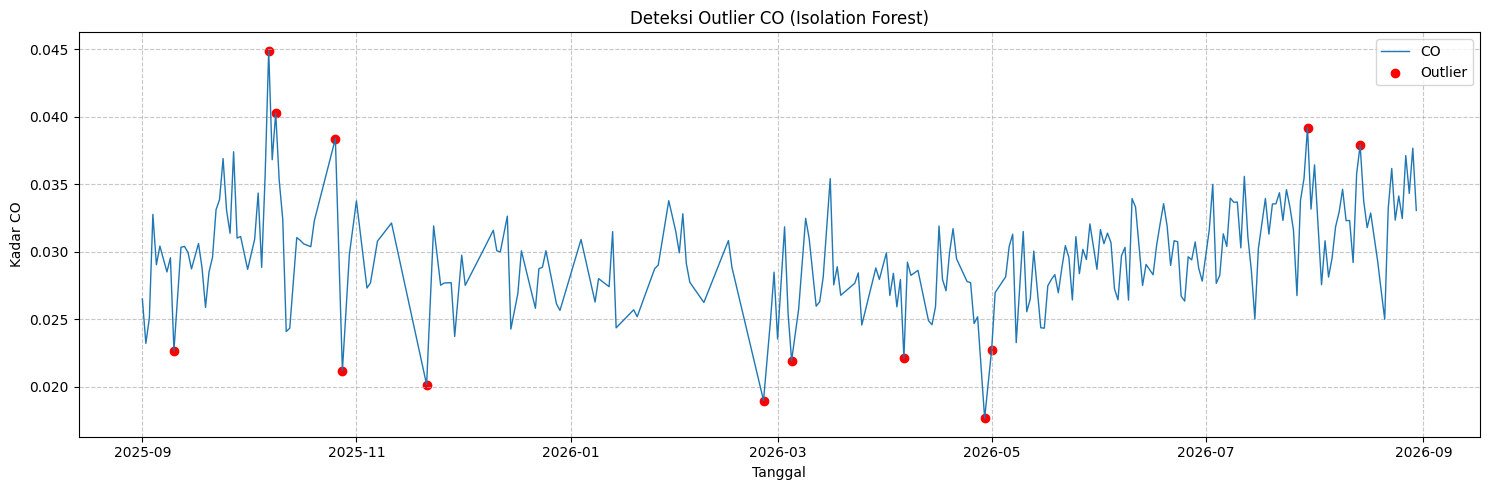

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

df = pd.read_csv("../../data/polutan/CO.csv")
df = df.dropna(subset=['CO']).copy()
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

model = IsolationForest(contamination=0.05, random_state=42)
pred = model.fit_predict(df[['CO']])

df['anomaly'] = pred
outliers = df[df['anomaly'] == -1]

print("Jumlah outlier CO:", len(outliers))
print(outliers[['date', 'CO']].head())

plt.figure(figsize=(15, 5))
plt.plot(df['date'], df['CO'], label='CO', linewidth=1)
plt.scatter(outliers['date'], outliers['CO'], color='red', label='Outlier')
plt.title('Deteksi Outlier CO (Isolation Forest)')
plt.xlabel('Tanggal')
plt.ylabel('Kadar CO')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### 2. SO₂

Jumlah outlier SO2: 14
                         date       SO2
10  2025-09-11 00:00:00+00:00 -0.000268
27  2025-10-01 00:00:00+00:00 -0.000253
39  2025-10-13 00:00:00+00:00 -0.000239
65  2025-11-21 00:00:00+00:00 -0.000356
117 2026-03-06 00:00:00+00:00 -0.000724


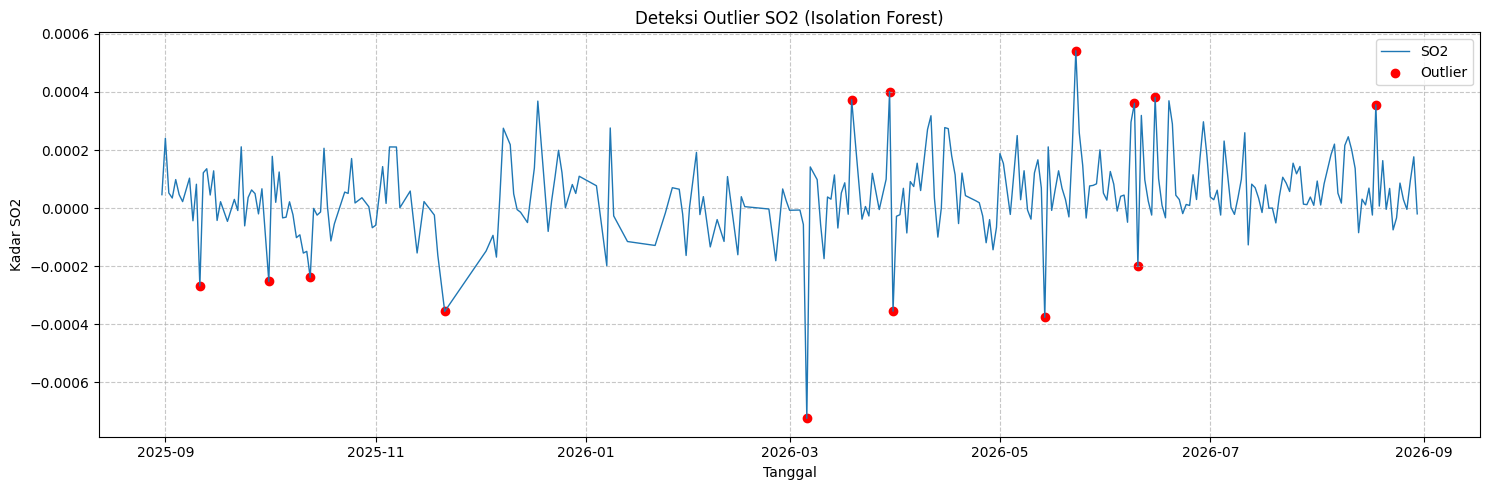

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

df = pd.read_csv("../../data/polutan/SO2.csv")
df = df.dropna(subset=['SO2']).copy()
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

model = IsolationForest(contamination=0.05, random_state=42)
pred = model.fit_predict(df[['SO2']])

df['anomaly'] = pred
outliers = df[df['anomaly'] == -1]

print("Jumlah outlier SO2:", len(outliers))
print(outliers[['date', 'SO2']].head())

plt.figure(figsize=(15, 5))
plt.plot(df['date'], df['SO2'], label='SO2', linewidth=1)
plt.scatter(outliers['date'], outliers['SO2'], color='red', label='Outlier')
plt.title('Deteksi Outlier SO2 (Isolation Forest)')
plt.xlabel('Tanggal')
plt.ylabel('Kadar SO2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### 3. NO₂

Jumlah outlier NO2: 13
                         date       NO2
21  2025-09-25 00:00:00+00:00  0.000054
71  2025-12-17 00:00:00+00:00  0.000013
80  2026-01-02 00:00:00+00:00  0.000011
84  2026-01-13 00:00:00+00:00  0.000011
141 2026-05-04 00:00:00+00:00  0.000057


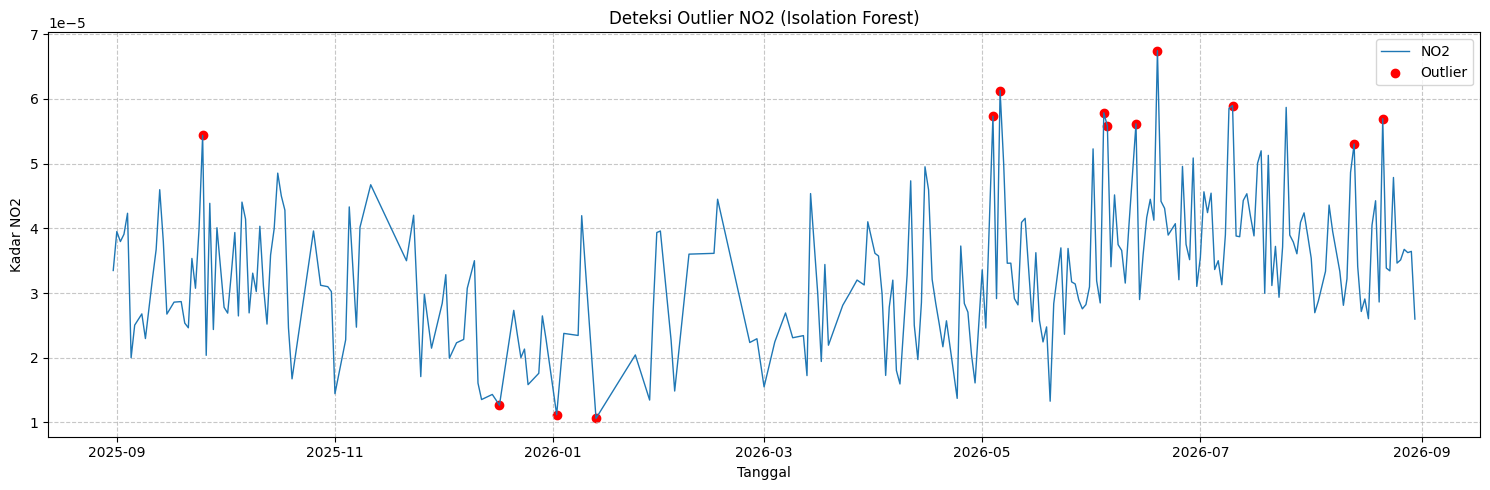

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

df = pd.read_csv("../../data/polutan/NO2.csv")
df = df.dropna(subset=['NO2']).copy()
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

model = IsolationForest(contamination=0.05, random_state=42)
pred = model.fit_predict(df[['NO2']])

df['anomaly'] = pred
outliers = df[df['anomaly'] == -1]

print("Jumlah outlier NO2:", len(outliers))
print(outliers[['date', 'NO2']].head())

plt.figure(figsize=(15, 5))
plt.plot(df['date'], df['NO2'], label='NO2', linewidth=1)
plt.scatter(outliers['date'], outliers['NO2'], color='red', label='Outlier')
plt.title('Deteksi Outlier NO2 (Isolation Forest)')
plt.xlabel('Tanggal')
plt.ylabel('Kadar NO2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

---

## Visualisasi Gabungan (CO, SO₂, NO₂)

Setelah proses pengecekan missing value dan outlier dilakukan, kita dapat melihat pola fluktuasi ketiga polutan secara bersamaan. Karena skala nilai ketiganya berbeda, maka dilakukan normalisasi Min-Max agar semua grafik bisa dibandingkan dalam satu sumbu yang sama.

Rumus normalisasi Min-Max adalah:

$$
X_{scaled} = \frac{X - X_{min}}{X_{max} - X_{min}}
$$

Dengan rumus ini, semua nilai akan berada pada rentang 0 sampai 1.

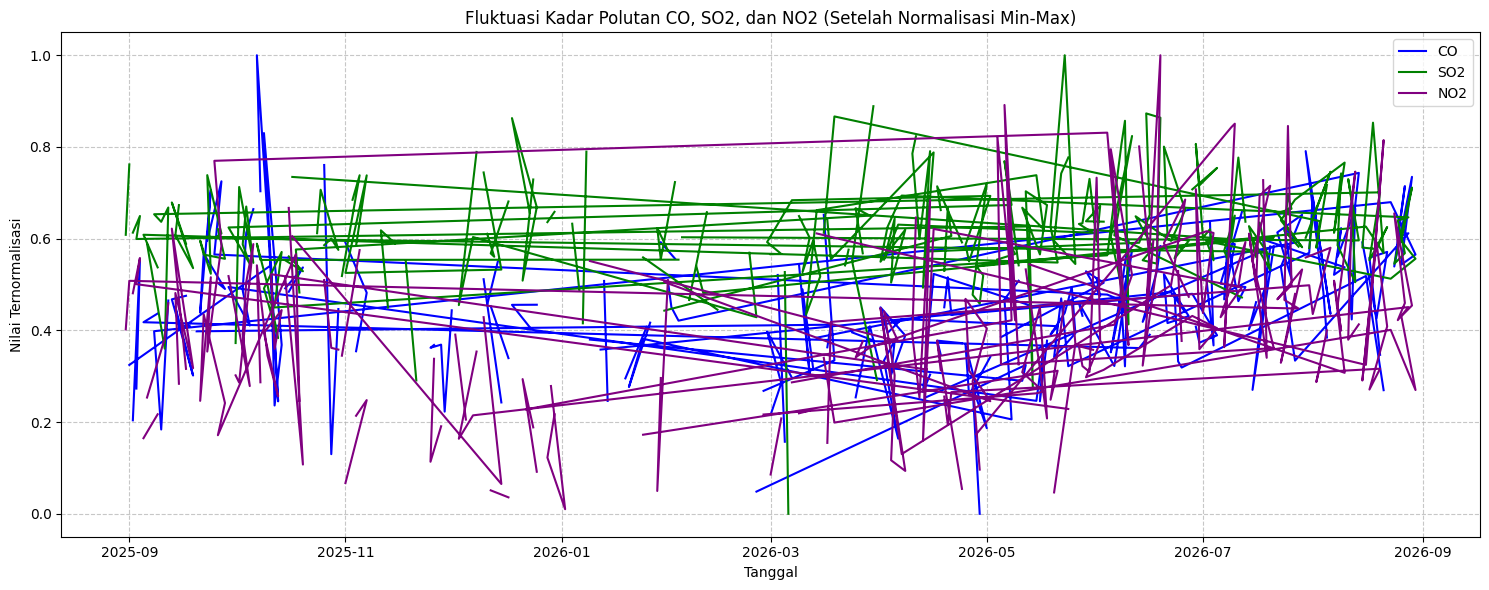

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

df_co = pd.read_csv("../../data/polutan/CO.csv")
df_so2 = pd.read_csv("../../data/polutan/SO2.csv")
df_no2 = pd.read_csv("../../data/polutan/NO2.csv")

df_co['date'] = pd.to_datetime(df_co['date'])
df_so2['date'] = pd.to_datetime(df_so2['date'])
df_no2['date'] = pd.to_datetime(df_no2['date'])

# Normalisasi Min-Max

df_co['CO_scaled'] = (df_co['CO'] - df_co['CO'].min()) / (df_co['CO'].max() - df_co['CO'].min())
df_so2['SO2_scaled'] = (df_so2['SO2'] - df_so2['SO2'].min()) / (df_so2['SO2'].max() - df_so2['SO2'].min())
df_no2['NO2_scaled'] = (df_no2['NO2'] - df_no2['NO2'].min()) / (df_no2['NO2'].max() - df_no2['NO2'].min())

plt.figure(figsize=(15, 6))
plt.plot(df_co['date'], df_co['CO_scaled'], label='CO', linewidth=1.5, color='blue')
plt.plot(df_so2['date'], df_so2['SO2_scaled'], label='SO2', linewidth=1.5, color='green')
plt.plot(df_no2['date'], df_no2['NO2_scaled'], label='NO2', linewidth=1.5, color='purple')

plt.title('Fluktuasi Kadar Polutan CO, SO2, dan NO2 (Setelah Normalisasi Min-Max)')
plt.xlabel('Tanggal')
plt.ylabel('Nilai Ternormalisasi')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

---

## Kesimpulan

Dari eksplorasi data, kita mengetahui bahwa dataset polutan masih mungkin mengandung:

- tanggal yang hilang
- nilai kosong (`NaN`)
- outlier yang perlu dibersihkan sebelum proses ekstraksi fitur

Tahap berikutnya adalah melakukan **preprocessing** untuk menangani missing value dan outlier, lalu menghasilkan data yang lebih bersih dan siap digunakan pada tahap ekstraksi fitur.